<a href="https://colab.research.google.com/github/harshs-data/Deep-Learning/blob/main/Sentiment_analysis(full_practiced_code_)BOW_TFIDF(ML).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [72]:
import pandas as pd
from datasets import load_dataset


raw_datasets = load_dataset("imdb")

df_train = raw_datasets['train'].to_pandas()
df_test = raw_datasets['test'].to_pandas()

df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True)
df_test = df_test.sample(frac=1, random_state=42).reset_index(drop=True)

df = pd.concat([df_train, df_test])

df

X = df.iloc[:,:1]
y = df.iloc[:, -1:]

In [73]:
X

,text
0,"Dumb is as dumb does, in this thoroughly unint..."
1,I dug out from my garage some old musicals and...
2,After watching this movie I was honestly disap...
3,This movie was nominated for best picture but ...
4,Just like Al Gore shook us up with his painful...
...,...
24995,It's possible to have a good time with this fi...
24996,'Illuminata' has expanded the limits of John T...
24997,Without being really the worst science fiction...
24998,"A film is beyond all expectations, an excellen..."


In [74]:
y

,label
0,0
1,1
2,0
3,1
4,1
...,...
24995,1
24996,0
24997,0
24998,1


In [75]:
df['label'].value_counts()

,count
label,
0,25000
1,25000


In [76]:
df.isnull().sum()

,0
text,0
label,0


In [77]:
df.duplicated().sum()

np.int64(418)

In [78]:
df.drop_duplicates(inplace=True)

In [79]:
df.shape

(49582, 2)

### Basic preprocessing
- remove html tags
- lower case
- remove stopwords

In [80]:
import re

def remove_tags(text):
  cleaned_text = re.sub(r'<.*?>', '', text)
  return cleaned_text

In [81]:
df['text'] = df['text'].apply(remove_tags)

In [82]:
def lower(text):
  cleaned_text = text.lower()
  return cleaned_text

In [83]:
df['text'] = df['text'].apply(lower)

In [84]:
df

,text,label
0,"dumb is as dumb does, in this thoroughly unint...",0
1,i dug out from my garage some old musicals and...,1
2,after watching this movie i was honestly disap...,0
3,this movie was nominated for best picture but ...,1
4,just like al gore shook us up with his painful...,1
...,...,...
24995,it's possible to have a good time with this fi...,1
24996,'illuminata' has expanded the limits of john t...,0
24997,without being really the worst science fiction...,0
24998,"a film is beyond all expectations, an excellen...",1


In [85]:
# remove punctuation

import string
def remove_punctuation(text):
  cleaned_text = re.sub(f'[{re.escape(string.punctuation)}]', '',text)
  return cleaned_text

In [86]:
df['text'] = df['text'].apply(remove_punctuation)

In [87]:
df

,text,label
0,dumb is as dumb does in this thoroughly uninte...,0
1,i dug out from my garage some old musicals and...,1
2,after watching this movie i was honestly disap...,0
3,this movie was nominated for best picture but ...,1
4,just like al gore shook us up with his painful...,1
...,...,...
24995,its possible to have a good time with this fil...,1
24996,illuminata has expanded the limits of john tur...,0
24997,without being really the worst science fiction...,0
24998,a film is beyond all expectations an excellent...,1


In [88]:
def remove_whitespace(text):
  cleaned_text = " ".join(text.split())
  return cleaned_text

In [89]:
df['text'] = df['text'].apply(remove_whitespace)

In [90]:
df

,text,label
0,dumb is as dumb does in this thoroughly uninte...,0
1,i dug out from my garage some old musicals and...,1
2,after watching this movie i was honestly disap...,0
3,this movie was nominated for best picture but ...,1
4,just like al gore shook us up with his painful...,1
...,...,...
24995,its possible to have a good time with this fil...,1
24996,illuminata has expanded the limits of john tur...,0
24997,without being really the worst science fiction...,0
24998,a film is beyond all expectations an excellent...,1


In [91]:
import nltk
from nltk.corpus import stopwords

# Download the stopwords list (only needs to be done once)
nltk.download('stopwords')

# Load the list of English stop words
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    # Split text into words
    words = text.split()
    # Rebuild the string, excluding words found in the stop_words set
    filtered_text = [word for word in words if word.lower() not in stop_words]
    return " ".join(filtered_text)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [92]:
df['text'] = df['text'].apply(remove_stopwords)

In [93]:
df

,text,label
0,dumb dumb thoroughly uninteresting supposed bl...,0
1,dug garage old musicals another one favorites ...,1
2,watching movie honestly disappointed actors st...,0
3,movie nominated best picture lost casablanca p...,1
4,like al gore shook us painfully honest cleverl...,1
...,...,...
24995,possible good time film time regretting isnt 1...,1
24996,illuminata expanded limits john turturros medi...,0
24997,without really worst science fiction film ever...,0
24998,film beyond expectations excellent insight hum...,1


In [94]:
X = df.iloc[:,:1]
y = df.iloc[:, -1:]

In [95]:
X

,text
0,dumb dumb thoroughly uninteresting supposed bl...
1,dug garage old musicals another one favorites ...
2,watching movie honestly disappointed actors st...
3,movie nominated best picture lost casablanca p...
4,like al gore shook us painfully honest cleverl...
...,...
24995,possible good time film time regretting isnt 1...
24996,illuminata expanded limits john turturros medi...
24997,without really worst science fiction film ever...
24998,film beyond expectations excellent insight hum...


In [96]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=42)

In [97]:
X_train.shape

(39665, 1)

### Applying BOW

In [98]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()

In [99]:
X_train_bow = cv.fit_transform(X_train['text'])
X_test_bow = cv.transform(X_test['text'])

In [100]:
X_train_bow.shape

(39665, 191594)

### Data Distribution for Naive Bayes

Before selecting a Naive Bayes model, it's useful to understand the characteristics of our Bag-of-Words (BoW) feature matrix. We'll look at the sparsity and the distribution of word counts per document.

Shape of X_train_bow: (39665, 191594)
Number of non-zero elements in X_train_bow: 3946848
Sparsity of X_train_bow: 99.95%


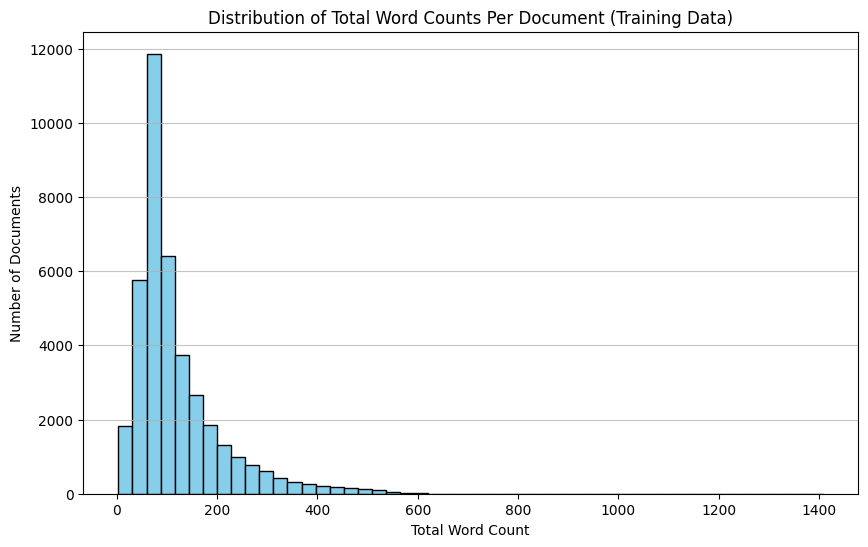

In [101]:
import matplotlib.pyplot as plt
import numpy as np

# Calculate sparsity
n_total_elements = X_train_bow.shape[0] * X_train_bow.shape[1]
n_non_zero_elements = X_train_bow.nnz
sparsity = (1 - (n_non_zero_elements / n_total_elements)) * 100

print(f"Shape of X_train_bow: {X_train_bow.shape}")
print(f"Number of non-zero elements in X_train_bow: {n_non_zero_elements}")
print(f"Sparsity of X_train_bow: {sparsity:.2f}%")

# Distribution of words (non-zero features) per document
word_counts_per_doc = X_train_bow.sum(axis=1).A.flatten()

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.hist(word_counts_per_doc, bins=50, color='skyblue', edgecolor='black')
ax.set_title('Distribution of Total Word Counts Per Document (Training Data)')
ax.set_xlabel('Total Word Count')
ax.set_ylabel('Number of Documents')
plt.grid(axis='y', alpha=0.75)
plt.show()

The high sparsity indicates that most documents only contain a small fraction of the total vocabulary. The histogram shows the distribution of word counts per document.

Given that `CountVectorizer` outputs integer counts of word occurrences, **Multinomial Naive Bayes** is generally the most appropriate choice. It models the probability of observing word counts for each class. Bernoulli Naive Bayes is more suited for binary features (presence/absence of a word), and Gaussian Naive Bayes is for continuous data, which is not what we have here. Therefore, we will proceed with Multinomial Naive Bayes.

In [102]:
from sklearn.naive_bayes import MultinomialNB

In [103]:
mnb = MultinomialNB()

In [104]:
mnb.fit(X_train_bow, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MultinomialNB()

In [105]:
y_pred = mnb.predict(X_test_bow)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix
accuracy_score(y_test, y_pred)

0.859332459413129

In [106]:
precision_score(y_test, y_pred)

0.8750771763737395

In [107]:
recall_score(y_test, y_pred)

0.8436507936507937

In [108]:
confusion_matrix(y_test, y_pred)

array([[4270,  607],
       [ 788, 4252]])

### Using TFIDF

In [120]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer()

In [121]:
X_train_tfidf = tfidf.fit_transform(X_train['text'])
X_test_tfidf = tfidf.transform(X_test['text'])

In [122]:
mnb_tf = MultinomialNB()

In [123]:
mnb_tf.fit(X_train_tfidf, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


MultinomialNB()

In [124]:
y_pred = mnb_tf.predict(X_test_tfidf)

accuracy_score(y_test, y_pred)

0.8647776545326208

### Prediction Time

In [143]:
!pip install  contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 14.3 MB/s eta 0:00:00


In [163]:
raw_text = '''it was a bad movie'''

In [164]:
import contractions

raw_text = contractions.fix(raw_text)

In [165]:
import re
import string
import nltk
from nltk.corpus import stopwords

# Ensure the stopwords are downloaded
nltk.download('stopwords')

def best_preprocess(raw_text):
    # 1. Lowercase
    raw_text = raw_text.lower()

    # 2. Remove HTML tags (common in IMDb)
    raw_text = re.sub(r'<br\s*/?>', ' ', raw_text) # Handles <br>, <br />, and <br/>
    raw_text = re.sub(r'<.*?>', '', raw_text)      # Handles any other HTML tags

    # 3. Remove Punctuation
    # We use a space to replace punctuation so words don't accidentally merge
    translator = str.maketrans(string.punctuation, ' ' * len(string.punctuation))
    raw_text = raw_text.translate(translator)

    # 4. Smart Stop-Word Removal
    stop_words = set(stopwords.words('english'))
    # IMPORTANT: Keep negation words for Sentiment Analysis!
    negations = {"not", "no", "never", "neither", "nor", "but", "isn't", "wasn't", "couldn't"}
    stop_words = stop_words - negations

    # 5. Tokenize and Filter
    # This removes stop words AND normalizes whitespace in one go
    words = raw_text.split()
    filtered_words = [word for word in words if word not in stop_words]

    return " ".join(filtered_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [166]:
best_preprocess(raw_text)

'bad movie'

In [167]:
raw_y_pred = mnb_tf.predict(tfidf.transform([best_preprocess(raw_text)]))

In [168]:
probability = mnb_tf.predict_proba(tfidf.transform([best_preprocess(raw_text)]))

# 6. Output the result
label = "Positive" if raw_y_pred[0] == 1 else "Negative"
confidence = np.max(probability) * 100

print(f"Review: {raw_text}")
print(f"Prediction: {label}")
print(f"Confidence: {confidence:.2f}%")

Review: it was a bad movie
Prediction: Negative
Confidence: 80.12%
